In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
uploaded = files.upload()

df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Saving titanic.csv to titanic.csv
Dataset loaded successfully.
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data Types:
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-

In [5]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

print(missing_values)

             Missing Values  Percentage
deck                    688   77.216611
age                     177   19.865320
embarked                  2    0.224467
embark_town               2    0.224467
sex                       0    0.000000
pclass                    0    0.000000
survived                  0    0.000000
fare                      0    0.000000
parch                     0    0.000000
sibsp                     0    0.000000
class                     0    0.000000
adult_male                0    0.000000
who                       0    0.000000
alive                     0    0.000000
alone                     0    0.000000


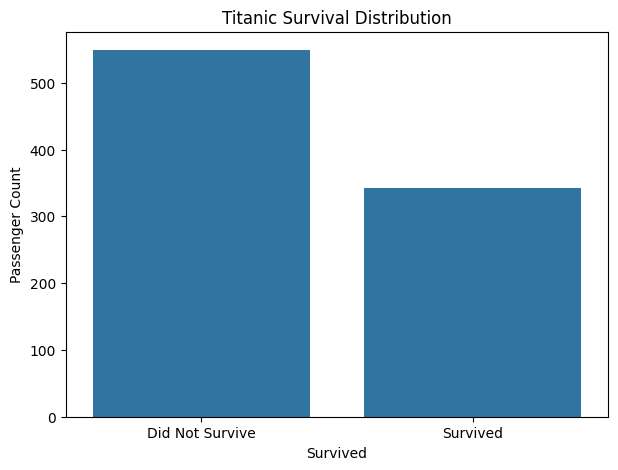

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="survived"
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.show()

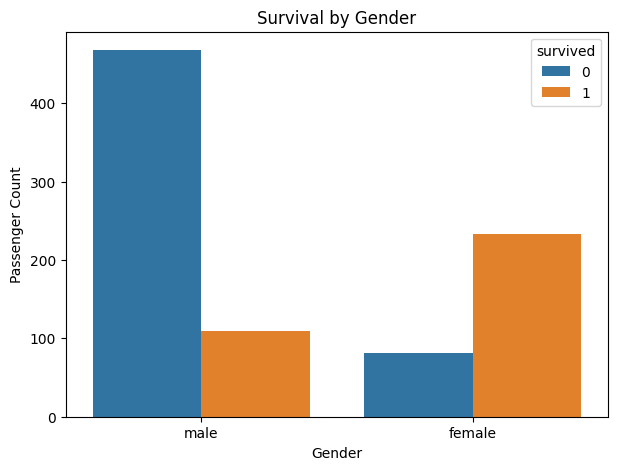

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sex",
    hue="survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.show()

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


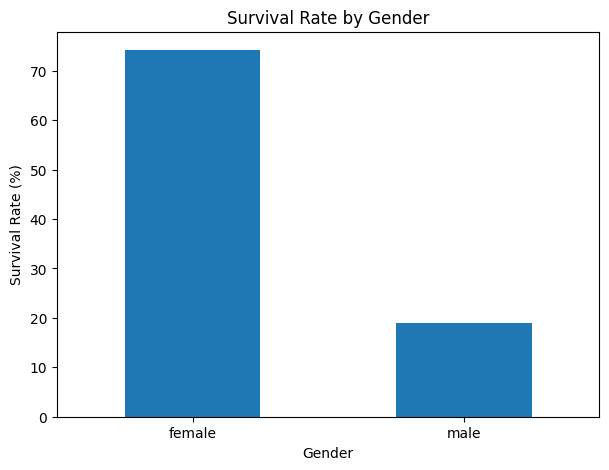

In [9]:
gender_survival = df.groupby("sex")["survived"].mean() * 100

print(gender_survival)

gender_survival.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

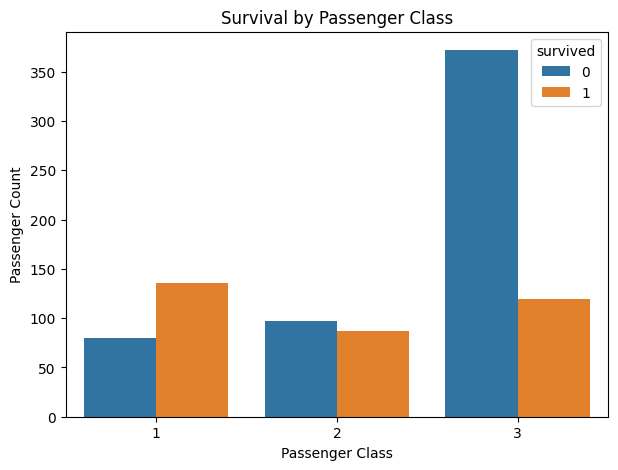

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="pclass",
    hue="survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")

plt.show()

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


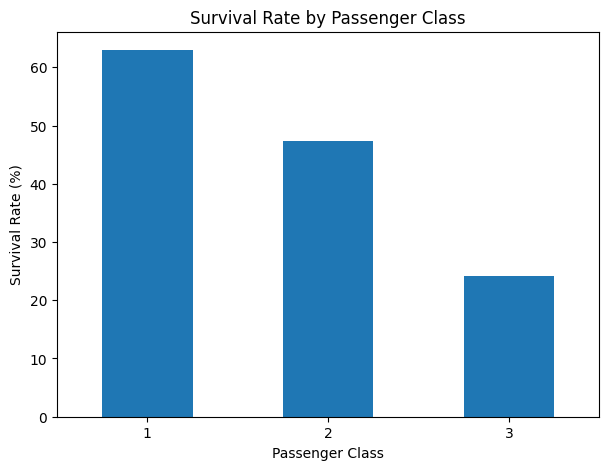

In [11]:
class_survival = df.groupby("pclass")["survived"].mean() * 100

print(class_survival)

class_survival.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

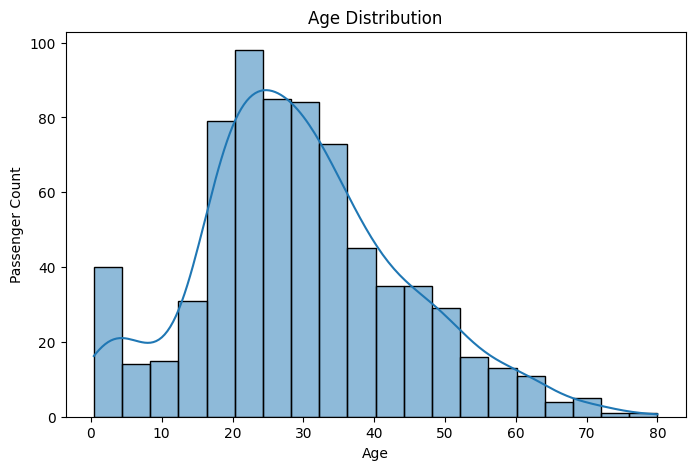

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passenger Count")

plt.show()

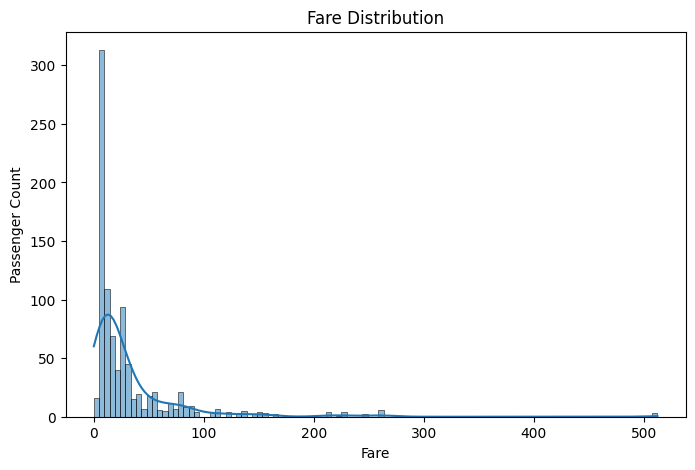

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="fare",
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Passenger Count")

plt.show()

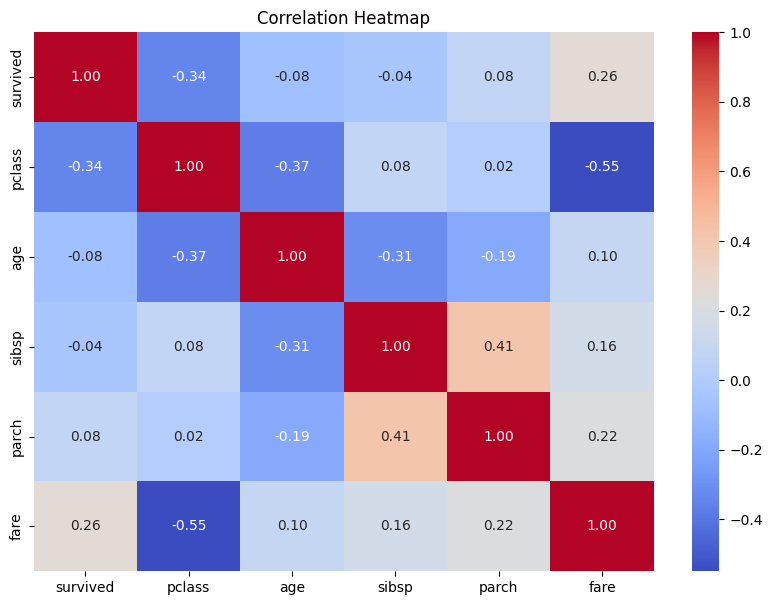

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
clean_df = df.copy()

# Fill numerical missing values
clean_df["age"] = clean_df["age"].fillna(
    clean_df["age"].median()
)

clean_df["fare"] = clean_df["fare"].fillna(
    clean_df["fare"].median()
)

# Fill categorical missing values
clean_df["embarked"] = clean_df["embarked"].fillna(
    clean_df["embarked"].mode()[0]
)

print("Missing values after basic cleaning:")
print(clean_df.isnull().sum())

Missing values after basic cleaning:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [16]:
clean_df["family_size"] = (
    clean_df["sibsp"] +
    clean_df["parch"] +
    1
)

clean_df["is_alone"] = (
    clean_df["family_size"] == 1
).astype(int)

print(
    clean_df[
        ["sibsp", "parch", "family_size", "is_alone"]
    ].head(10)
)

   sibsp  parch  family_size  is_alone
0      1      0            2         0
1      1      0            2         0
2      0      0            1         1
3      1      0            2         0
4      0      0            1         1
5      0      0            1         1
6      0      0            1         1
7      3      1            5         0
8      0      2            3         0
9      1      0            2         0


In [17]:
cluster_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

cluster_data = clean_df[cluster_features].copy()

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_data
)

print("Clustering data prepared.")

Clustering data prepared.


In [18]:
inertias = []
silhouette_scores = []

K_range = range(2, 9)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(cluster_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(
            cluster_scaled,
            labels
        )
    )

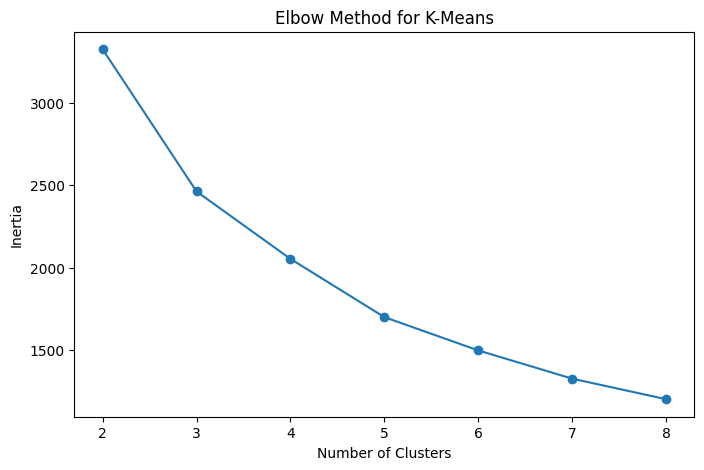

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    inertias,
    marker="o"
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

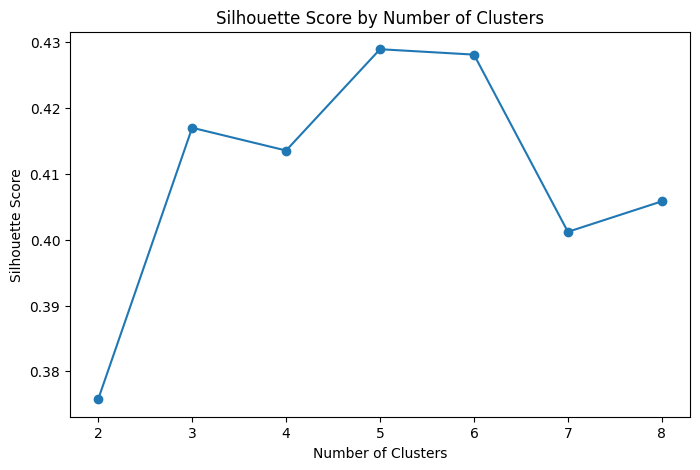

K=2: Silhouette Score=0.3758
K=3: Silhouette Score=0.4170
K=4: Silhouette Score=0.4136
K=5: Silhouette Score=0.4289
K=6: Silhouette Score=0.4281
K=7: Silhouette Score=0.4012
K=8: Silhouette Score=0.4058


In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")

In [21]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clean_df["cluster"] = kmeans.fit_predict(
    cluster_scaled
)

print(
    clean_df["cluster"].value_counts().sort_index()
)

cluster
0    110
1    542
2    239
Name: count, dtype: int64


In [22]:
cluster_summary = clean_df.groupby("cluster").agg({
    "age": "mean",
    "fare": "mean",
    "pclass": "mean",
    "sibsp": "mean",
    "parch": "mean",
    "survived": "mean"
})

cluster_summary["survival_rate"] = (
    cluster_summary["survived"] * 100
)

cluster_summary = cluster_summary.drop(
    columns="survived"
)

print(cluster_summary)

               age       fare    pclass     sibsp     parch  survival_rate
cluster                                                                   
0        15.088636  45.921856  2.572727  2.336364  1.936364      45.454545
1        27.788598  12.191819  2.771218  0.225092  0.110701      28.413284
2        39.497908  71.274390  1.138075  0.364017  0.280335      57.740586


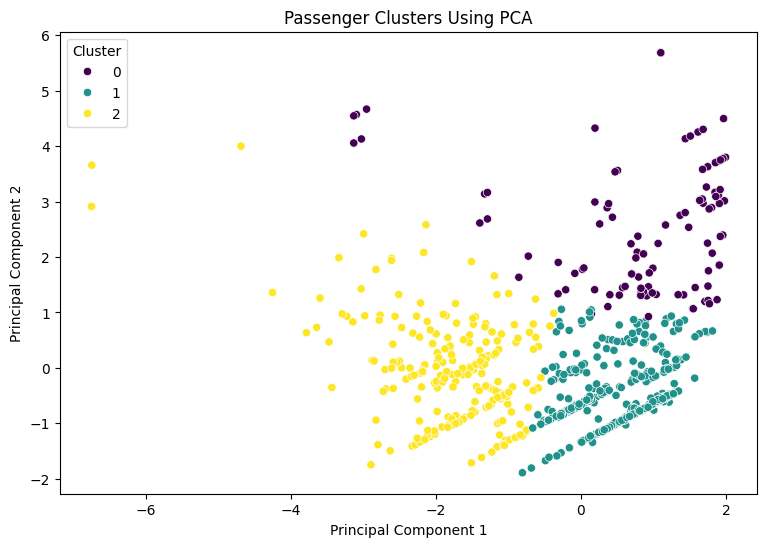

Explained variance: [0.33960812 0.32520788]
Total explained variance: 0.6648159969553279


In [23]:
pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(
    cluster_scaled
)

pca_df = pd.DataFrame(
    cluster_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clean_df["cluster"].values

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis"
)

plt.title("Passenger Clusters Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

In [24]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "family_size",
    "is_alone"
]

X = clean_df[features]

y = clean_df["survived"]

print("Features:", features)
print("Target:", "survived")

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone']
Target: survived


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [28]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "is_alone"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [27]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test
)

logistic_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


In [29]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest trained.")

Random Forest trained.


In [30]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    probability
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        probability
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [31]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_probability
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_probability
    )
)

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.804469   0.783333  0.681159  0.728682  0.851383
1        Random Forest  0.810056   0.830189  0.637681  0.721311  0.840711


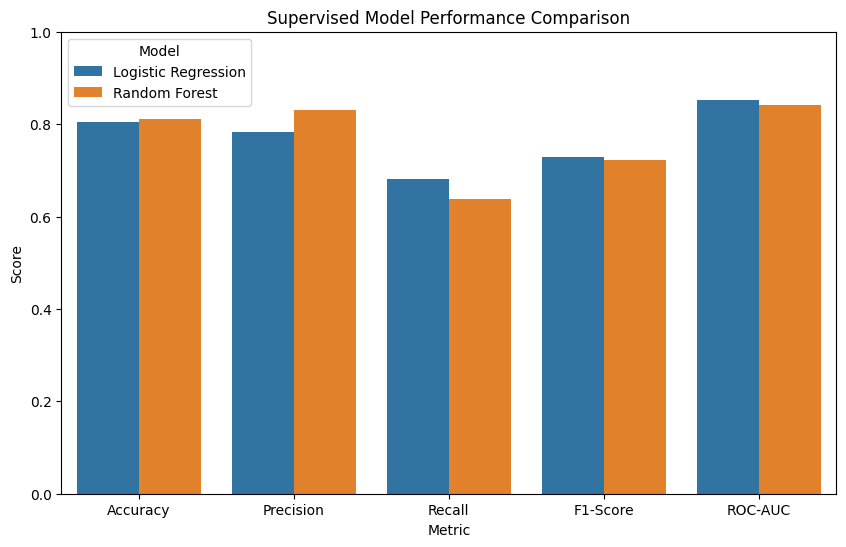

In [32]:
results_melted = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Supervised Model Performance Comparison")
plt.ylim(0, 1)

plt.show()

In [33]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       110
           1       0.83      0.64      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



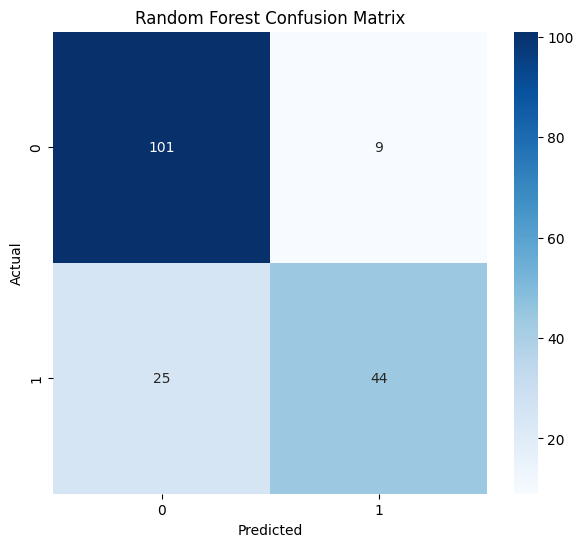

In [34]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

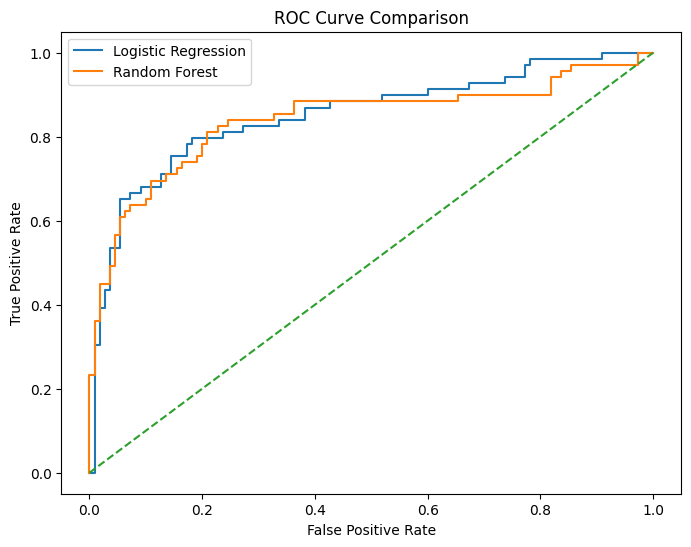

In [35]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    logistic_probability
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [36]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation scores:")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(
    f"\nMean CV Accuracy: "
    f"{cv_scores.mean():.4f}"
)

print(
    f"CV Standard Deviation: "
    f"{cv_scores.std():.4f}"
)

Cross-validation scores:
Fold 1: 0.8492
Fold 2: 0.8202
Fold 3: 0.8090
Fold 4: 0.8315
Fold 5: 0.8596

Mean CV Accuracy: 0.8339
CV Standard Deviation: 0.0185


In [37]:
rf_classifier = rf_model.named_steps[
    "classifier"
]

preprocessor_fitted = rf_model.named_steps[
    "preprocessor"
]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

             Feature  Importance
8      cat__sex_male    0.228325
7    cat__sex_female    0.188251
4          num__fare    0.179276
1           num__age    0.138696
0        num__pclass    0.111608
5   num__family_size    0.052023
2         num__sibsp    0.027099
3         num__parch    0.021726
11   cat__embarked_S    0.019477
6      num__is_alone    0.013720
9    cat__embarked_C    0.013050
10   cat__embarked_Q    0.006749


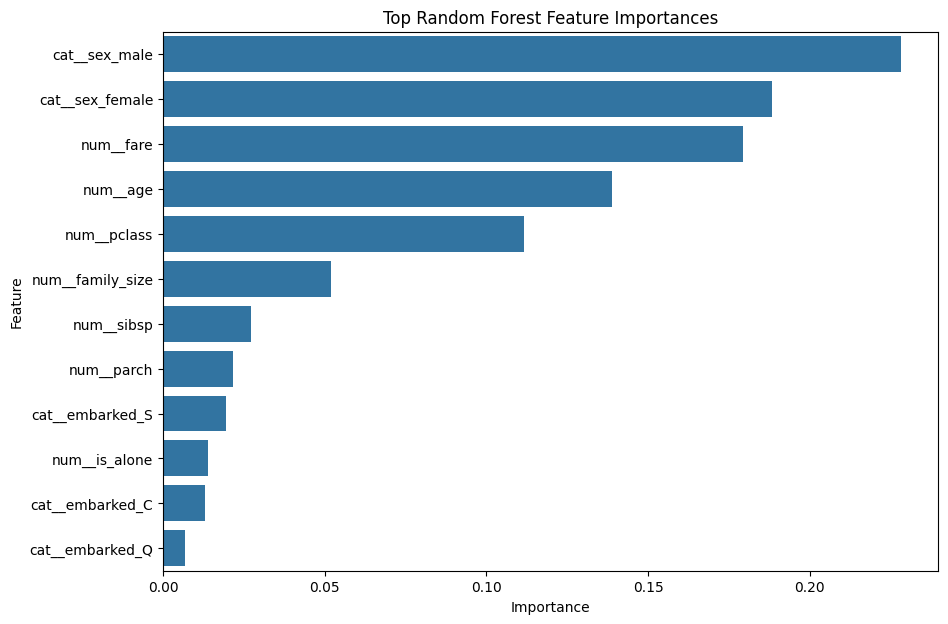

In [38]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df.head(12),
    x="Importance",
    y="Feature"
)

plt.title("Top Random Forest Feature Importances")

plt.show()

In [39]:
cluster_survival = (
    clean_df.groupby("cluster")["survived"]
    .mean() * 100
)

print(
    "Survival Rate by Cluster:"
)

print(cluster_survival)

Survival Rate by Cluster:
cluster
0    45.454545
1    28.413284
2    57.740586
Name: survived, dtype: float64


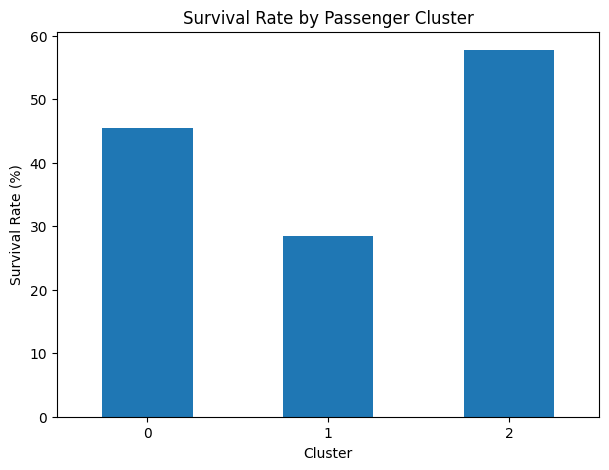

In [40]:
cluster_survival.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Survival Rate by Passenger Cluster")
plt.xlabel("Cluster")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [41]:
prediction_output = X_test.copy()

prediction_output["Actual_Survival"] = y_test.values
prediction_output["Predicted_Survival"] = rf_pred
prediction_output["Prediction_Probability"] = rf_probability

prediction_output.to_csv(
    "titanic_capstone_predictions.csv",
    index=False
)

print(
    "Prediction file saved successfully."
)

Prediction file saved successfully.


In [42]:
print("=" * 60)
print("WEEK 6 INTEGRATIVE CAPSTONE PROJECT")
print("=" * 60)

print("\nDataset:")
print("Titanic Passenger Dataset")

print("\nOriginal Dataset Shape:")
print(df.shape)

print("\nCleaned Dataset Shape:")
print(clean_df.shape)

print("\nClustering:")
print("K-Means with 3 clusters")

print("\nSupervised Models:")
print("1. Logistic Regression")
print("2. Random Forest")

print(
    f"\nRandom Forest Test Accuracy: "
    f"{results_df.loc[results_df['Model'] == 'Random Forest', 'Accuracy'].iloc[0] * 100:.2f}%"
)

print(
    f"Mean 5-Fold CV Accuracy: "
    f"{cv_scores.mean() * 100:.2f}%"
)

print("\nOutput:")
print("titanic_capstone_predictions.csv")

print("=" * 60)

WEEK 6 INTEGRATIVE CAPSTONE PROJECT

Dataset:
Titanic Passenger Dataset

Original Dataset Shape:
(891, 15)

Cleaned Dataset Shape:
(891, 18)

Clustering:
K-Means with 3 clusters

Supervised Models:
1. Logistic Regression
2. Random Forest

Random Forest Test Accuracy: 81.01%
Mean 5-Fold CV Accuracy: 83.39%

Output:
titanic_capstone_predictions.csv
